In [1]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import slide_fs_tools as sfs
from matplotlib.colors import Normalize

obs_file = "data/BforStrain_WUS_9_28_2022_smooth_trimesh.txt"

lat0 = 35
lon0 = -116
nom_node_spacing = 15

# mesh is expected to be a dict containing nodes, tri, tri_centroids, elts, and tri_areas
# here, I create it from a matlab file.

mesh_file = "data/CSAF_mesh.mat"
tmp_mesh = loadmat(mesh_file)
mesh = {
    "nodes": tmp_mesh["nodes"],
    "tri": tmp_mesh["tri"] - 1, 
    "tri_areas": tmp_mesh["tri_areas"],
    "tri_centroids": tmp_mesh["tri_centroids"],
}

mesh["elts"] = mesh["nodes"][mesh["tri"]]


faultinfo_file = "data/fault_info_CSAF.mat"
FaultInfo = loadmat(faultinfo_file)["FaultInfo"].ravel()

# get_observation_coords() is specific to this observation file format.
xy_obs, E_means, E_stds = sfs.get_observation_coords(obs_file, mesh, lon0, lat0)
# xy_obs is an n x 2 numpy array of locations with strain rate measurements, Exx, Exy, Eyy
# where d is a vector of length n*3 that stacks these measurements up (e.g. Exx for the first n, Exy for n+1 to 2n, and Eyy for 2n+1 to end)
# Esig follows the same convention
d = E_means.T.flatten()
Esig = E_stds.T.flatten()

In [ ]:
# besides the mesh, observation grid, and FaultInfo file, the only other parameters to specify are the locking depth (dlock_max), patch length (pL), and total vertical elements (total_nve)
# SliDeFS discretizes the creeping faults into a standardized format to solve for backslip. pL is the desired standardized patch length in km. For patches shorter than pL, they will be left as is
# for patches longer than pL, they will be split into multiple patches over which to calculate Green's functions
# after discretizing into standardized horizontal patches, faults are projected down-dip to a maximum depth of dlock_max and then split into total_nve vertical elements.
# so for this default scenario, 

cent_SAF_GFs = sfs.build_GFs(
    FaultInfo,
    mesh,
    xy_obs,
    dlock_max=20.0,
    pL=15,
    total_nve=3,
    variable_rake=True,
    include_moment=True,
    calc_visco=False,
    tri_mom=True,
    use_gaussian_prior=False,
    nu=0.25,
)
cent_SAF_GFs.compute_all()

Calculating shallow patch Green's Functions
Calculating deep patch Green's Functions
Calculating perpendicular rake shallow patch Green's Functions
Calculating perpendicular rake deep patch Green's Functions
Calculating moment source Green's Functions
Performing triangular moment source calculations. This is time intensive.


In [ ]:
cent_SAF_inv = sfs.Inversion(cent_SAF_GFs, d, Esig)

In [ ]:
# can be computed this way, via a wrapper function that simply runs everything manually
results = cent_SAF_inv.compute_all()

In [ ]:
# or via this series of commands, allowing for user specification of some additonal parametesr
# here I modify the moment source damping parameter

cent_SAF_inv.build_G()
cent_SAF_inv.set_bounds()
cent_SAF_inv.normalize_and_weight(weight_moment=2000)
cent_SAF_inv.run_inversion(verbose=False)
results = cent_SAF_inv.post_process()
cent_SAF_inv.disp_moments()

                                     CVXPY                                     
                                     v1.5.3                                    
(CVXPY) Feb 18 04:19:28 PM: Your problem has 5145 variables, 10290 constraints, and 0 parameters.
(CVXPY) Feb 18 04:19:28 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 18 04:19:28 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 18 04:19:28 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 18 04:19:28 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 18 04:19:28 PM: Compiling problem (target solver=OSQP)

In [ ]:
all_Ms = cent_SAF_inv.sample_posteriors()

In [ ]:
print("results structure:")

sfs.print_dict_tree(results)

results structure:
strain
   Exx_obs: np.ndarray, shape=(791,)
   Exy_obs: np.ndarray, shape=(791,)
   Eyy_obs: np.ndarray, shape=(791,)
   Exx_tot: np.ndarray, shape=(791,)
   Exy_tot: np.ndarray, shape=(791,)
   Eyy_tot: np.ndarray, shape=(791,)
   Exx_bs: np.ndarray, shape=(791,)
   Exy_bs: np.ndarray, shape=(791,)
   Eyy_bs: np.ndarray, shape=(791,)
   Exx_bf: np.ndarray, shape=(791,)
   Exy_bf: np.ndarray, shape=(791,)
   Eyy_bf: np.ndarray, shape=(791,)
shear
   max_shear_mean: np.ndarray, shape=(791,)
   max_shear_bs: np.ndarray, shape=(791,)
   max_shear_bf: np.ndarray, shape=(791,)
   max_shear_tot: np.ndarray, shape=(791,)
   max_shear_resid: np.ndarray, shape=(791,)
dilatation
   dilatation_mean: np.ndarray, shape=(791,)
   dilatation_bs: np.ndarray, shape=(791,)
   dilatation_bf: np.ndarray, shape=(791,)
   dilatation_tot: np.ndarray, shape=(791,)
   dilatation_resid: np.ndarray, shape=(791,)
rake
   rake_top_mod: np.ndarray, shape=(152,)
   rake_bot_mod: np.ndarray, shape=

In [ ]:
print("Computed total strain rates are the sum of the On-fault (Exx_bs) and Off-fault (Exx_bf) or body force strain rates")
print(np.allclose(results["strain"]["Eyy_tot"],results["strain"]["Eyy_bs"]+results["strain"]["Eyy_bf"]))

Computed total strain rates are the sum of the On-fault (Exx_bs) and Off-fault (Exx_bf) or body force strain rates
True


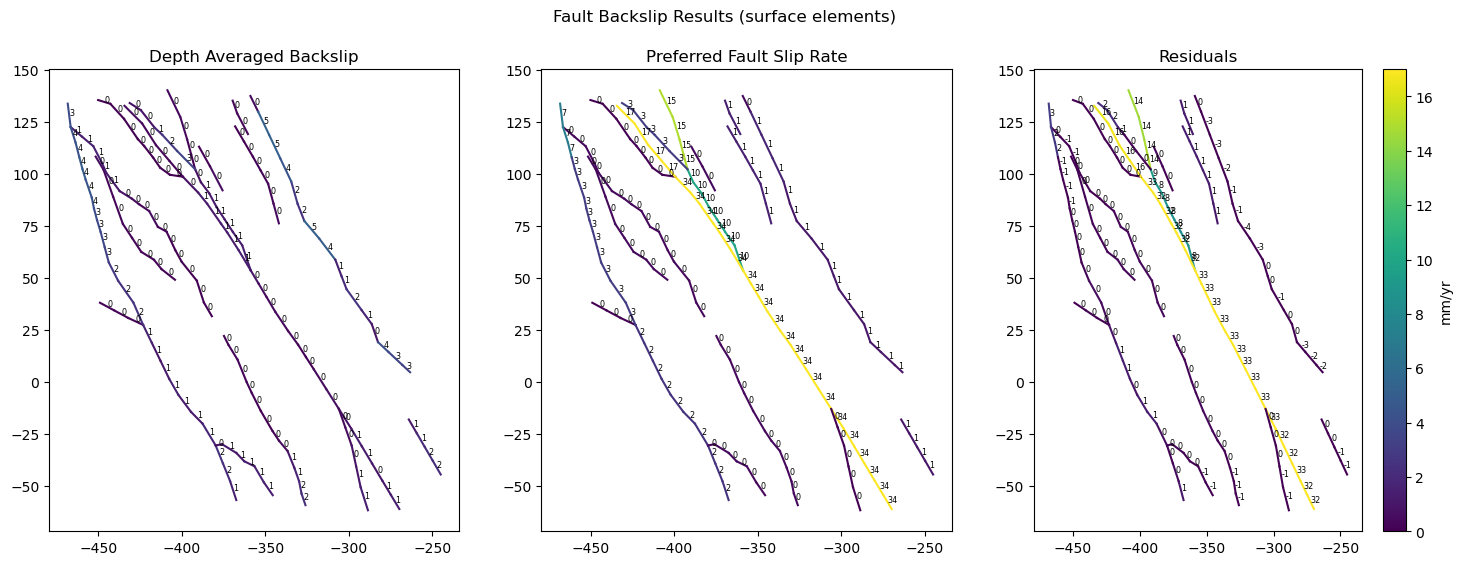

In [ ]:
scale = 1e3

backslip = np.vstack((results["slip"]["bs_top_tot"], results["slip"]["bs_bot_tot"].reshape(-1, 2).T))
backslip = np.vstack((results["slip"]["bs_bot_tot"].reshape(-1, 2).T)) # ignore top row
backslip = backslip.mean(axis=0) # depth averaged

preferred_rate = [fault.slip for fault in cent_SAF_inv.faults_top for seg in fault.segments]

cnt = 0
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

all_slip_values = (backslip + preferred_rate) / 2

norm = Normalize(vmin=min(all_slip_values), vmax=max(all_slip_values))


for fault in cent_SAF_inv.faults_top:
    for patch in fault.segments:

        color_bs = backslip[cnt] * scale
        xs = patch.geometry[:, 0]
        ys = patch.geometry[:, 1]

        ax[0].plot(xs, ys, color=cm.viridis(norm(color_bs)))

        ax[0].text(
            xs.mean(),
            ys.mean(),
            str(int(color_bs)),
            fontsize="xx-small",
        )
        cnt += 1

cnt = 0

for fault in cent_SAF_inv.faults_top:
    for patch in fault.segments:
        color_slip = preferred_rate[cnt]
        xs = patch.geometry[:, 0]
        ys = patch.geometry[:, 1]

        ax[1].plot(xs, ys, color=cm.viridis(norm(color_slip)))

        ax[1].text(
            xs.mean(),
            ys.mean(),
            str(int(color_slip)),
            fontsize="xx-small",
        )

        cnt +=1

cnt = 0
for fault in cent_SAF_inv.faults_top:
    for patch in fault.segments:
        color_slip = preferred_rate[cnt] - backslip[cnt] * scale
        xs = patch.geometry[:, 0]
        ys = patch.geometry[:, 1]

        ax[2].plot(xs, ys, color=cm.viridis(norm(color_slip)))

        ax[2].text(
            xs.mean(),
            ys.mean(),
            str(int(color_slip)),
            fontsize="xx-small",
        )
        cnt +=1
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
fig.colorbar(sm, ax=ax[2], orientation="vertical", label="mm/yr")

ax[0].set_title("Depth Averaged Backslip")
ax[1].set_title("Preferred Fault Slip Rate")
ax[2].set_title('Residuals')
plt.suptitle("Fault Backslip Results (surface elements)")
plt.show()

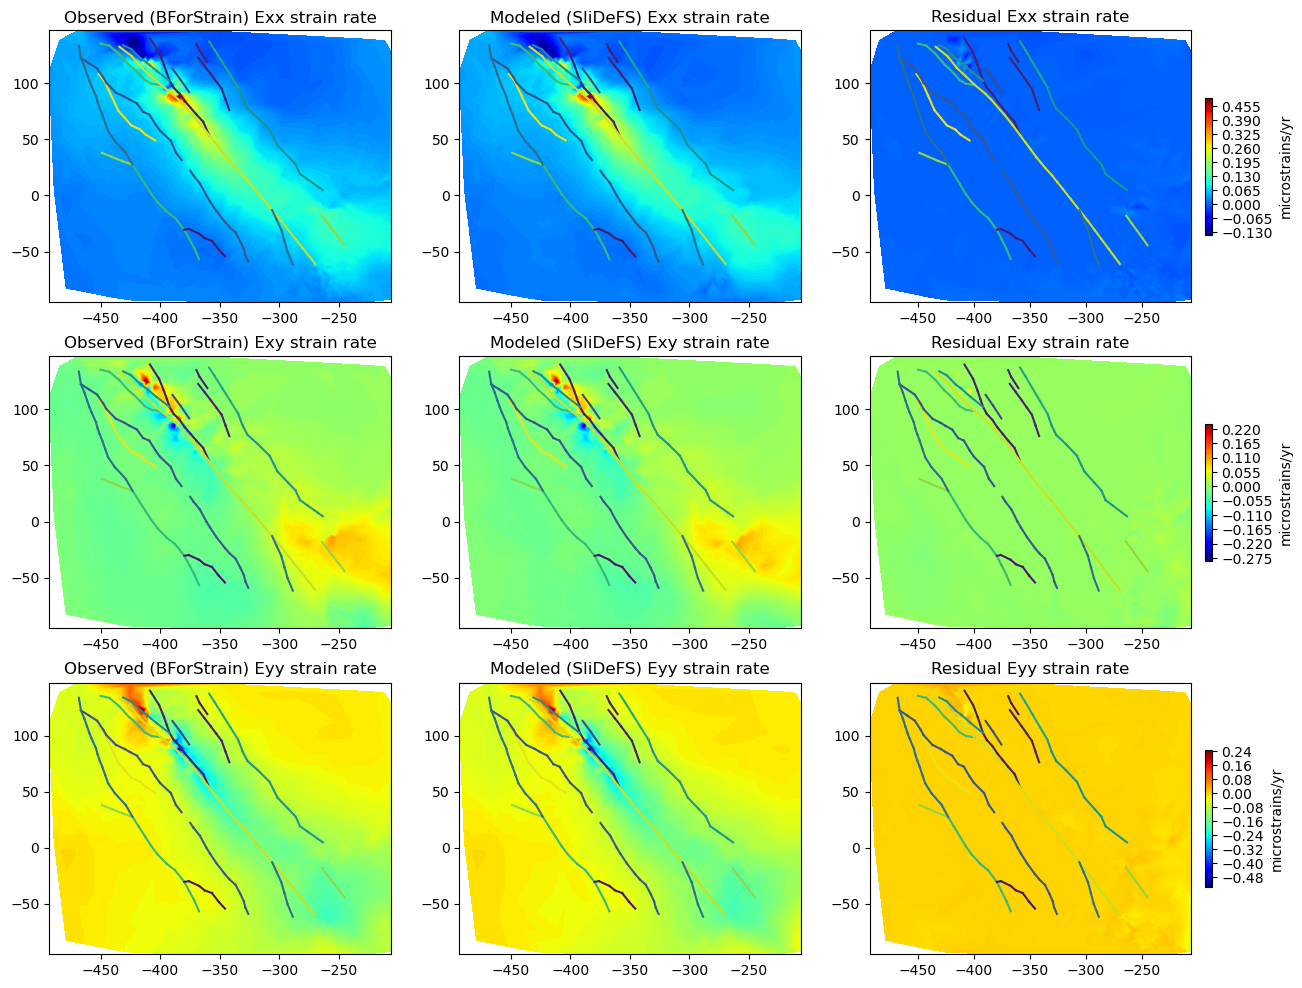

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(15, 12))

# Define strain components to plot
strain_components = ["Exx", "Exy", "Eyy"]
scale=1e6
for i, comp in enumerate(strain_components):
    # Define a common color scale for all three plots
    norm = plt.Normalize(
        vmin=min(
            np.min(results["strain"][f"{comp}_obs"]),
            np.min(results["strain"][f"{comp}_tot"]),
            np.min(results["strain"][f"{comp}_obs"] - results["strain"][f"{comp}_tot"]),
        )*scale,
        vmax=max(
            np.max(results["strain"][f"{comp}_obs"]),
            np.max(results["strain"][f"{comp}_tot"]),
            np.max(results["strain"][f"{comp}_obs"] - results["strain"][f"{comp}_tot"]),
        )*scale,
    )

    # Plot observed data
    ax[i, 0].tricontourf(
        xy_obs[:, 0],
        xy_obs[:, 1],
        results["strain"][f"{comp}_obs"]*scale,
        levels=127,
        cmap="jet",
        norm=norm,
    )

    for fault in cent_SAF_inv.faults_top:
        color_value = fault.fault_id % 181
        color = cm.viridis(color_value / 181)

        for patch in fault.segments:
            xs = patch.geometry[:, 0]
            ys = patch.geometry[:, 1]
            ax[i, 0].plot(xs, ys, color=color)

    ax[i, 0].set_title(f"Observed (BForStrain) {comp} strain rate")

    # Plot modeled data
    for fault in cent_SAF_inv.faults_top:
        color_value = fault.fault_id % 181
        color = cm.viridis(color_value / 181)

        for patch in fault.segments:
            xs = patch.geometry[:, 0]
            ys = patch.geometry[:, 1]
            ax[i, 1].plot(xs, ys, color=color)

    c2 = ax[i, 1].tricontourf(
        xy_obs[:, 0],
        xy_obs[:, 1],
        results["strain"][f"{comp}_tot"] * scale,
        levels=127,
        cmap="jet",
        norm=norm,
    )
    ax[i, 1].set_title(f"Modeled (SliDeFS) {comp} strain rate")

    # Plot residuals
    for fault in cent_SAF_inv.faults_top:
        color_value = fault.fault_id % 181
        color = cm.viridis(color_value / 181)

        for patch in fault.segments:
            xs = patch.geometry[:, 0]
            ys = patch.geometry[:, 1]
            ax[i, 2].plot(xs, ys, color=color)

    c3 = ax[i, 2].tricontourf(
        xy_obs[:, 0],
        xy_obs[:, 1],
        (results["strain"][f"{comp}_obs"] - results["strain"][f"{comp}_tot"]) * scale,
        levels=127,
        cmap="jet",
        norm=norm,
    )
    ax[i, 2].set_title(f"Residual {comp} strain rate")

    cbar = fig.colorbar(c2, ax=ax[i,2], orientation="vertical", fraction=0.02, pad=0.04)
    cbar.set_label("microstrains/yr")

plt.show()

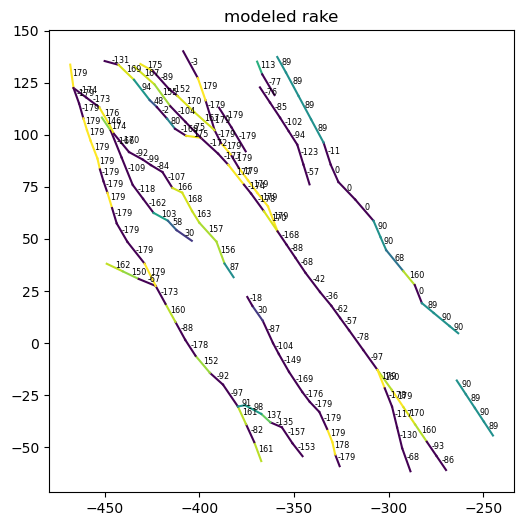

In [ ]:
cnt = 0
fig, ax = plt.subplots(figsize=(6, 6))
for fault in cent_SAF_inv.faults_top:

    for patch in fault.segments:
        one_rake = results["rake"]["rake_top_mod"][cnt]
        color = one_rake
        xs = patch.geometry[:, 0]
        ys = patch.geometry[:, 1]
        ax.plot(xs, ys, color=cm.viridis(color/180))
        cnt += 1

        ax.text(
            xs.mean(),
            ys.mean(),
            str(int(color)),
            fontsize="xx-small",
        )
plt.title('modeled rake')
plt.show()

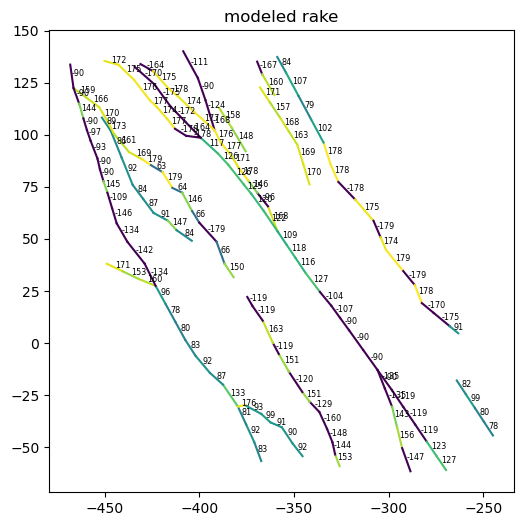

In [ ]:
cnt = 0
fig, ax = plt.subplots(figsize=(6, 6))
for fault in cent_SAF_inv.faults_top:

    for patch in fault.segments:
        color = results["rake"]["rake_bot_mod"][cnt]
        xs = patch.geometry[:, 0]
        ys = patch.geometry[:, 1]
        ax.plot(xs, ys, color=cm.viridis(color / 180))
        cnt += 1

        ax.text(
            xs.mean(),
            ys.mean(),
            str(int(color)),
            fontsize="xx-small",
        )
plt.title("modeled rake")
plt.show()

In [ ]:
# for other scenario

faultinfo_file = "data/fault_info_NoCal_novisco.mat"
mesh_file = "data/NoCal_mesh.mat"

lon0 = -121
lat0 = 39
h0 = 0